libraries import karege

In [89]:
import pandas as pd 
import matplotlib.pyplot as plt

Data ko import and read karege

In [90]:
df = pd.read_csv("Superstore sales dataset.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2025-152156,08-11-2025,11-11-2025,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2025-152156,08-11-2025,11-11-2025,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2025-138688,12-06-2025,16-06-2025,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2023-108966,11-10-2023,18-10-2023,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2023-108966,11-10-2023,18-10-2023,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


Data ka type pata karege 

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

Check karege koi missing value to nahi hai

In [92]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [93]:
df = df.dropna(subset=["Order Date"])

Date column ko date me convert karege

In [ ]:
df["Order Date"]=pd.to_datetime(df["Order Date"],format="%d-%m-%Y",errors="coerce")
df["Ship Date"] = pd.to_datetime(df["Ship Date"],format="%d-%m-%Y")

Column name ko clean kara

In [95]:
df.columns = df.columns.str.lower().str.replace(" ","_")

In [96]:
df.head()

,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2025-152156,2025-11-08,2025-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2025-152156,2025-11-08,2025-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2025-138688,2025-06-12,2025-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2023-108966,2023-10-11,2023-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2023-108966,2023-10-11,2023-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


drop_duplicates() ka kam ye hta hai ki kisi column me suppose id 101 101 do bar aajae to use single 101 bana dega 

Split into 3 Tables

In [97]:
orders = df[[
    "order_id","order_date","ship_date",
    "customer_id","product_id",
    "sales","quantity","profit","discount"
]].drop_duplicates()

In [98]:
customers = df[[
    "customer_id","customer_name",
    "segment","region","city","state"
]].drop_duplicates()

In [99]:
products = df[[
    "product_id","product_name",
    "category","sub-category"
]].drop_duplicates()


Ab three of them ko ek csv file me save karege

In [100]:
orders.to_csv("orders.csv", index=False)
customers.to_csv("customers.csv", index=False)
products.to_csv("products.csv", index=False)

order_date ko index ki taraha set kar diya hai

In [101]:
df.set_index("order_date", inplace=True)

Data Analysis Overview

Sales Trend: Time ke saath sales pattern 

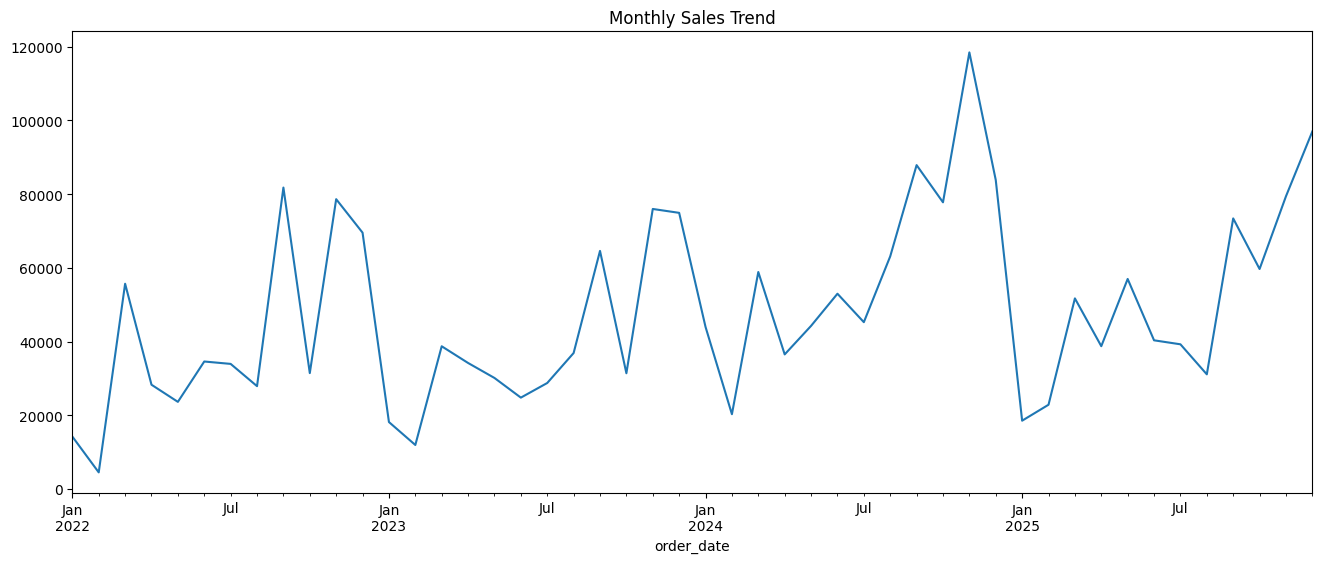

In [107]:
sales_trend = df["sales"].resample("MS").sum()
sales_trend.plot(figsize=(16,6))
plt.title("Monthly Sales Trend")
plt.show()

Region-wise Sales: Best performing regions

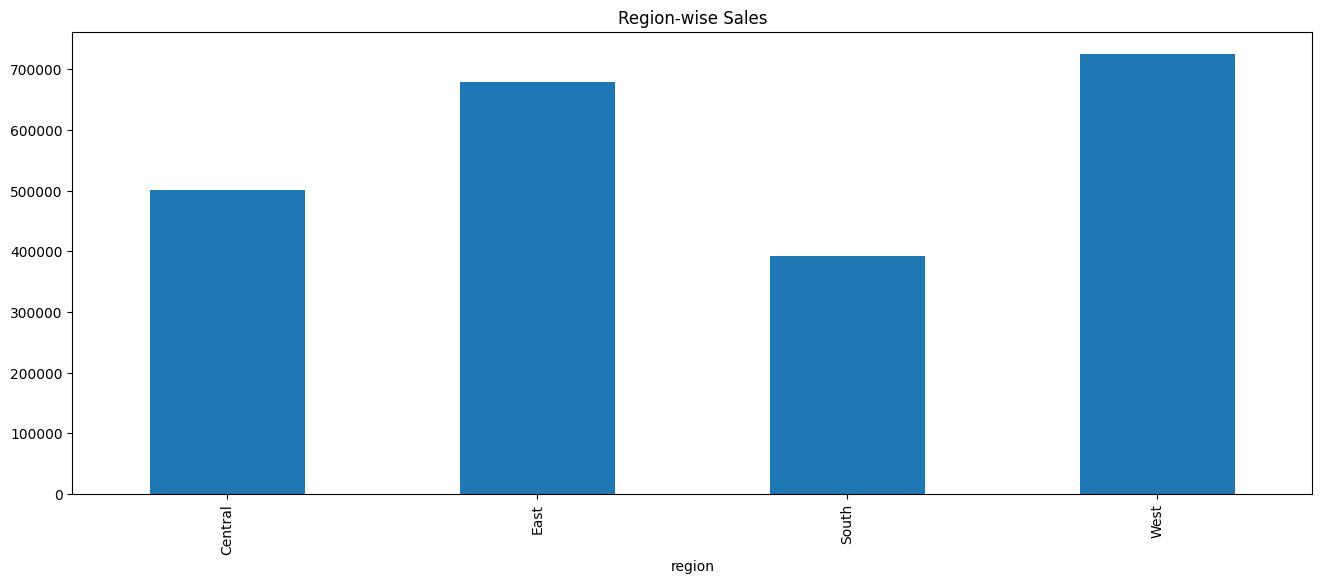

In [109]:
region_sales = df.groupby("region")["sales"].sum()
region_sales.plot(kind='bar',figsize=(16,6))
plt.title("Region-wise Sales")
plt.show()

 Category-wise Sales: Top performing categories

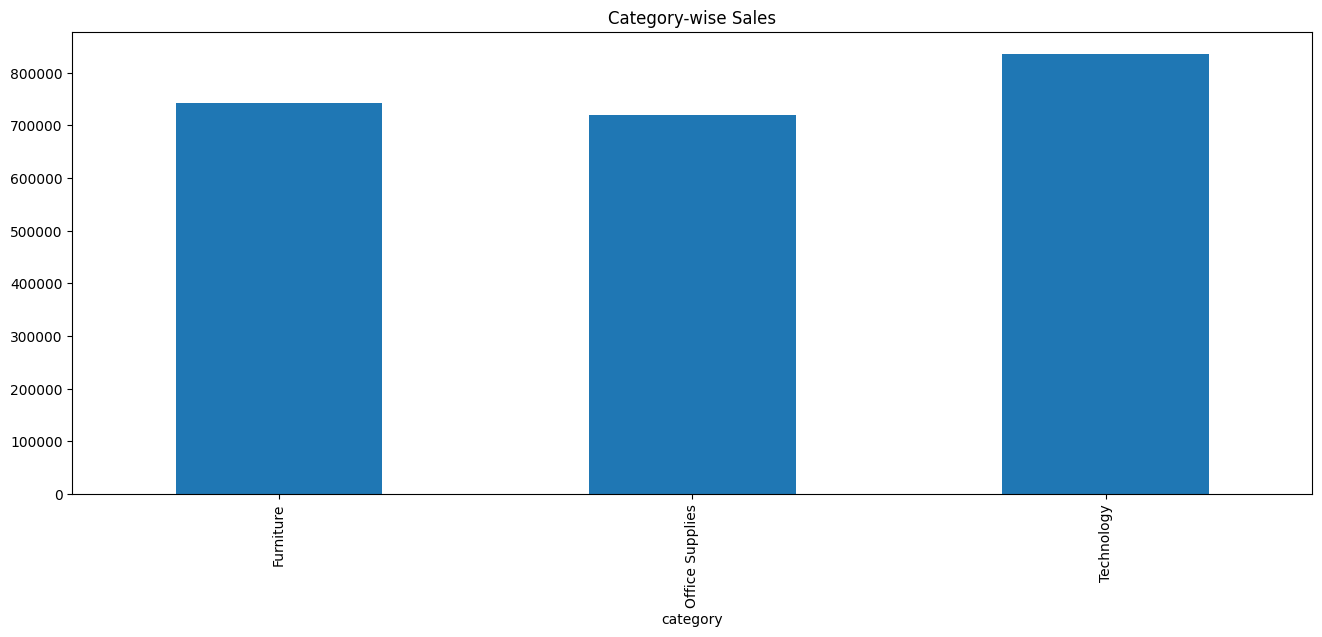

In [111]:
category_sales = df.groupby("category")["sales"].sum()
category_sales.plot(kind='bar',figsize=(16,6))
plt.title("Category-wise Sales")
plt.show()